In [9]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tifffile

In [16]:
data_dir = Path(r"C:\Users\User\Desktop\白血球画像分類\Stained_Montages\CRF022\B\batch1")

ch1_path = data_dir / "ch1_1.tif"
ch3_path = data_dir / "ch3_1.tif"
ch5_path = data_dir / "ch5_1.tif"

In [17]:
ch1 = tifffile.imread(ch1_path)
ch3 = tifffile.imread(ch3_path)
ch5 = tifffile.imread(ch5_path)

print("ch1:", ch1.shape, ch1.dtype)
print("ch3:", ch3.shape, ch3.dtype)
print("ch5:", ch5.shape, ch5.dtype)

ch1: (1650, 1650) float32
ch3: (1650, 1650) float32
ch5: (1650, 1650) float32


In [18]:
for name, img in {
    "ch1": ch1,
    "ch3": ch3,
    "ch5": ch5
}.items():

    print(
        name,
        "min =", img.min(),
        "max =", img.max(),
        "mean =", img.mean()
    )

ch1 min = 0.0 max = 0.009613184 mean = 0.000104934814
ch3 min = 0.0 max = 0.004150454 mean = 0.00014359225
ch5 min = 0.0 max = 0.0045471885 mean = 0.0007552345


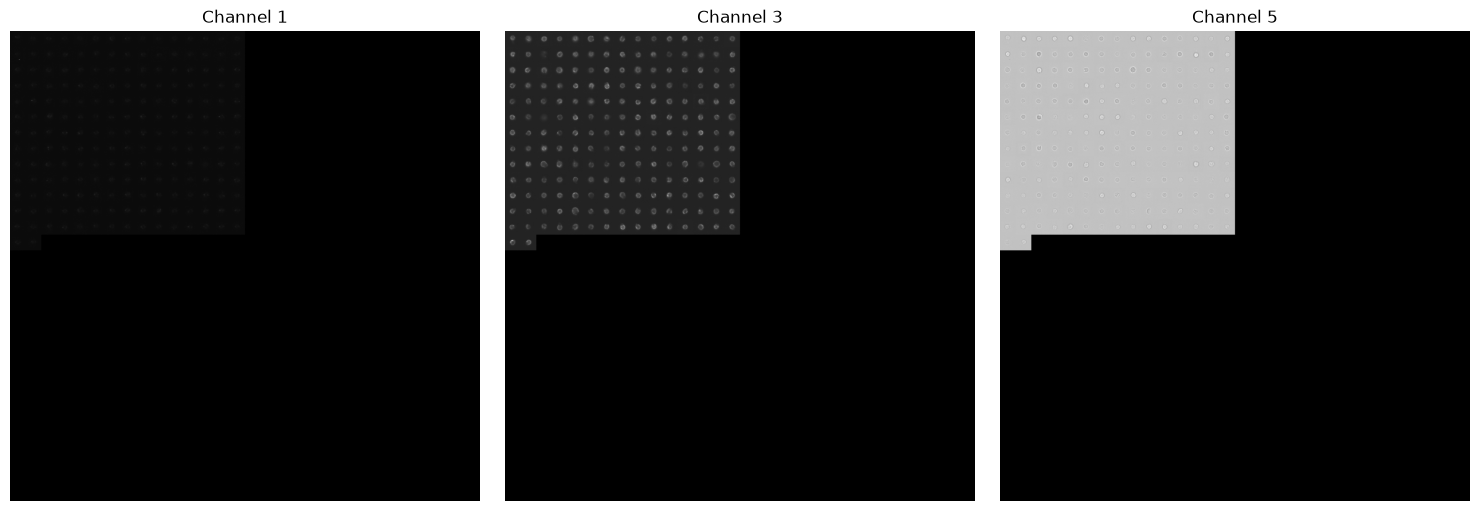

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

images = [ch1, ch3, ch5]
titles = [
    "Channel 1",
    "Channel 3",
    "Channel 5"
]

for ax, img, title in zip(axes, images, titles):
    ax.imshow(img, cmap="gray")
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [20]:
CELL_SIZE = 55
GRID_SIZE = 1650 // CELL_SIZE

print("Grid size:", GRID_SIZE, "x", GRID_SIZE)

Grid size: 30 x 30


<h3>細胞があるところを確認</h3>

In [21]:
valid_positions = []

for row in range(GRID_SIZE):
    for col in range(GRID_SIZE):

        y1 = row * CELL_SIZE
        y2 = y1 + CELL_SIZE

        x1 = col * CELL_SIZE
        x2 = x1 + CELL_SIZE

        cell = ch5[y1:y2, x1:x2]

        if np.any(cell != 0):
            valid_positions.append((row, col))

print("Number of cells:", len(valid_positions))
print("First positions:", valid_positions[:10])

Number of cells: 197
First positions: [(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (0, 9)]


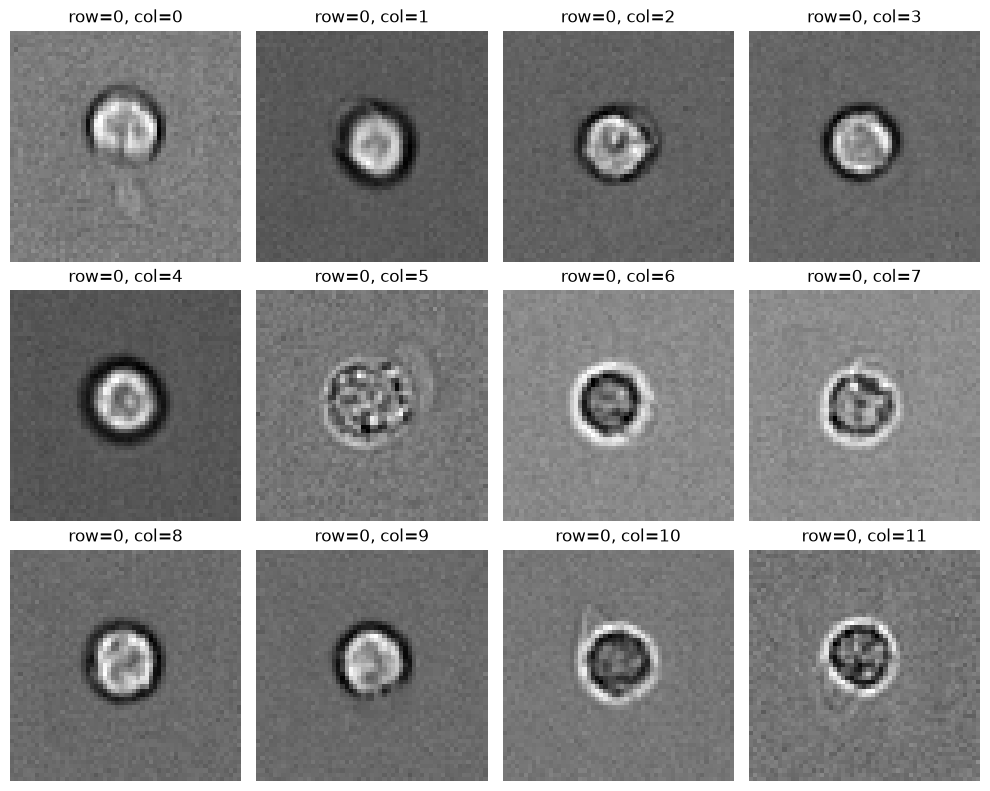

In [22]:
fig, axes = plt.subplots(3, 4, figsize=(10, 8))

for ax, (row, col) in zip(axes.flatten(), valid_positions[:12]):

    y1 = row * CELL_SIZE
    y2 = y1 + CELL_SIZE

    x1 = col * CELL_SIZE
    x2 = x1 + CELL_SIZE

    cell = ch5[y1:y2, x1:x2]

    ax.imshow(cell, cmap="gray")
    ax.set_title(f"row={row}, col={col}")
    ax.axis("off")

plt.tight_layout()
plt.show()

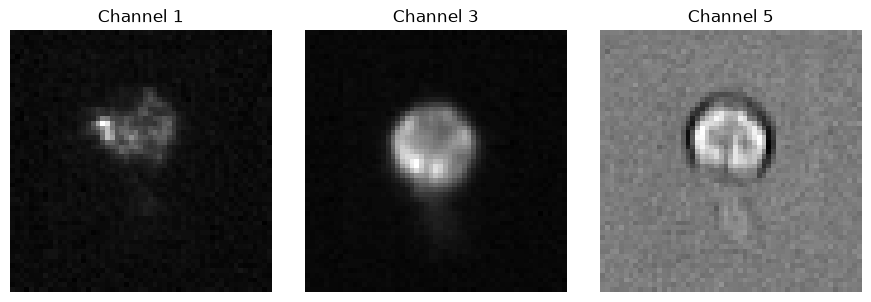

In [23]:
row, col = valid_positions[0]

y1 = row * CELL_SIZE
y2 = y1 + CELL_SIZE
x1 = col * CELL_SIZE
x2 = x1 + CELL_SIZE

cell_ch1 = ch1[y1:y2, x1:x2]
cell_ch3 = ch3[y1:y2, x1:x2]
cell_ch5 = ch5[y1:y2, x1:x2]

fig, axes = plt.subplots(1, 3, figsize=(9, 3))

for ax, cell, title in zip(
    axes,
    [cell_ch1, cell_ch3, cell_ch5],
    ["Channel 1", "Channel 3", "Channel 5"]
):
    ax.imshow(cell, cmap="gray")
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

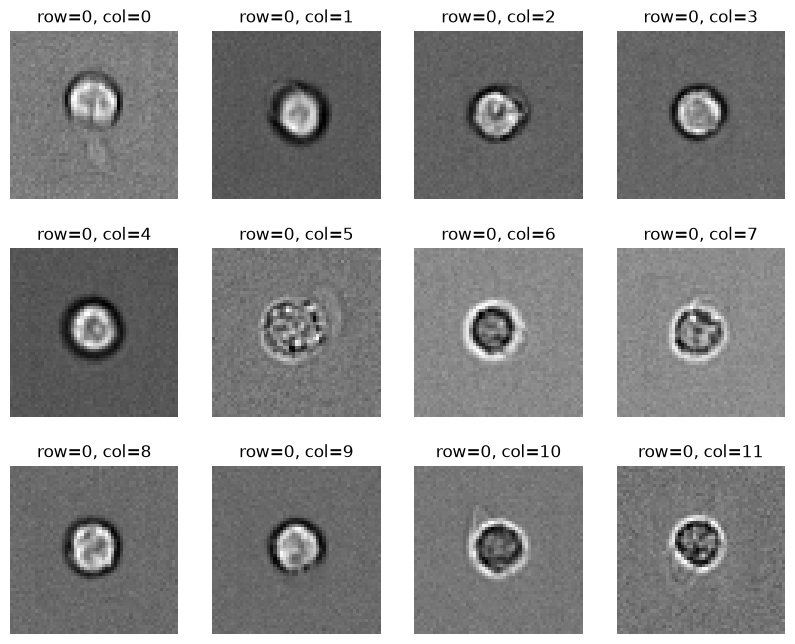

In [25]:
fig, axes = plt.subplots(3, 4, figsize=(10, 8))

for ax, (row, col) in zip(axes.flatten(), valid_positions[:12]):
    y1 = row * CELL_SIZE
    y2 = y1 + CELL_SIZE
    x1 = col * CELL_SIZE
    x2 = x1 + CELL_SIZE
    cell = ch5[y1:y2, x1:x2]
    ax.imshow(cell, cmap="gray")
    ax.set_title(f"row={row}, col={col}")
    ax.axis("off")

In [26]:
cells = []
for num,(row,col) in enumerate(valid_positions):
    y1 = row * CELL_SIZE
    y2 = y1 + CELL_SIZE
    x1 = col * CELL_SIZE
    x2 = x1 + CELL_SIZE
    cell_ch1 = ch1[y1:y2,x1:x2]
    cell_ch3 = ch3[y1:y2,x1:x2]
    cell_ch5 = ch5[y1:y2,x1:x2]
    cell_dict ={
    "cell_id":num,
    "row":row,
    "col":col,
    "ch1":cell_ch1,
    "ch3":cell_ch3,
    "ch5":cell_ch5
    }
    cells.append(cell_dict)
    

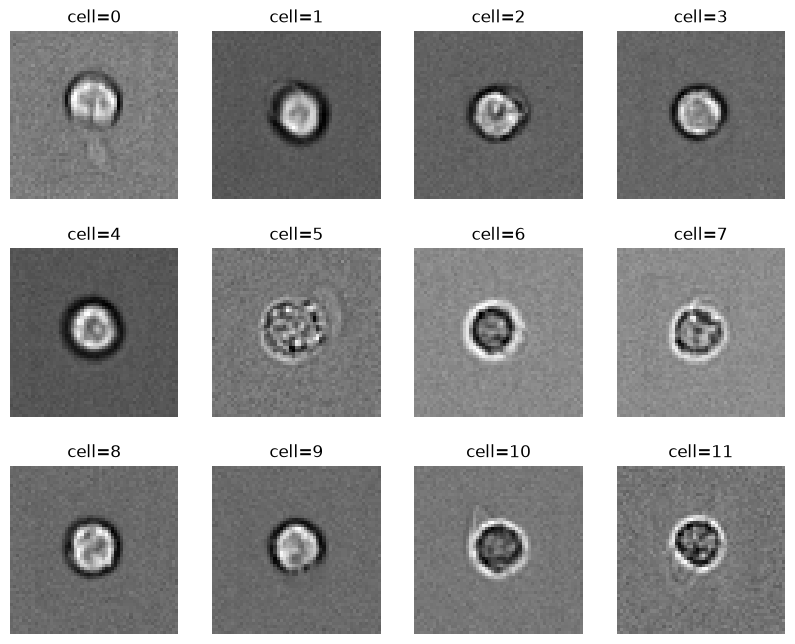

In [31]:
fig, axes = plt.subplots(3,4, figsize=(10, 8))

for ax, cell in zip(axes.flatten(), cells[:12]):
    ax.imshow(cell["ch5"], cmap="gray")
    ax.set_title(
        f'cell={cell["cell_id"]}'
    )
    ax.axis("off")

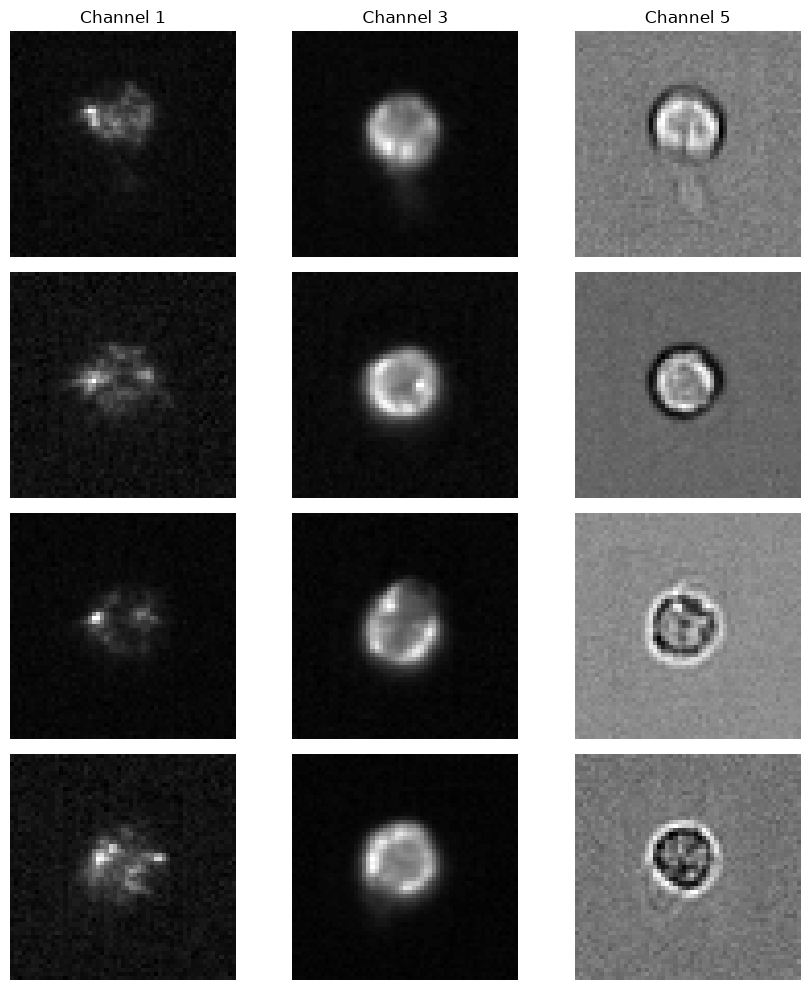

In [32]:
check_ids = [0, 3, 7, 11]

fig, axes = plt.subplots(len(check_ids), 3, figsize=(9, 10))

for row_idx, cell_id in enumerate(check_ids):
    cell = cells[cell_id]

    for col_idx, (ch, title) in enumerate(zip(
        [cell["ch1"], cell["ch3"], cell["ch5"]],
        ["Channel 1", "Channel 3", "Channel 5"]
    )):
        ax = axes[row_idx, col_idx]
        ax.imshow(ch, cmap="gray")

        if row_idx == 0:
            ax.set_title(title)

        if col_idx == 0:
            ax.set_ylabel(f"cell={cell_id}")

        ax.axis("off")

plt.tight_layout()
plt.show()

<h3>関数化</h3>

In [54]:
BASE_DIR = Path(
    r"C:\Users\User\Desktop\白血球画像分類\Stained_Montages"
)
def cell_batch(subject, class_name, batch):

    data_dir = BASE_DIR / subject / class_name / batch

    # Find all ch1 montage files
    ch1_files = sorted(data_dir.glob("ch1_*.tif"))

    if len(ch1_files) == 0:
        raise ValueError(f"No channel files found: {data_dir}")

    all_cells = []
    cell_counter = 0

    for ch1_path in ch1_files:

        # Get montage number: ch1_1.tif -> "1"
        montage_id = ch1_path.stem.split("_")[-1]

        ch3_path = data_dir / f"ch3_{montage_id}.tif"
        ch5_path = data_dir / f"ch5_{montage_id}.tif"

        # Check corresponding files exist
        if not ch3_path.exists() or not ch5_path.exists():
            raise ValueError(
                f"Missing channel pair for montage {montage_id}: {data_dir}"
            )

        # Convert to NumPy arrays
        ch1 = tifffile.imread(ch1_path)
        ch3 = tifffile.imread(ch3_path)
        ch5 = tifffile.imread(ch5_path)

        # Check shapes
        if not (ch1.shape == ch3.shape == ch5.shape):
            raise ValueError(
                f"Channel shapes do not match: "
                f"ch1={ch1.shape}, ch3={ch3.shape}, ch5={ch5.shape}"
            )

        valid_positions = []

        # Find cells
        for row in range(GRID_SIZE):
            for col in range(GRID_SIZE):

                y1 = row * CELL_SIZE
                y2 = y1 + CELL_SIZE

                x1 = col * CELL_SIZE
                x2 = x1 + CELL_SIZE

                cell = ch5[y1:y2, x1:x2]

                if np.any(cell != 0):
                    valid_positions.append((row, col))

        print(
            f"{subject} / {class_name} / {batch} / montage {montage_id}: "
            f"{len(valid_positions)} cells"
        )

        # Crop cells
        for row, col in valid_positions:

            y1 = row * CELL_SIZE
            y2 = y1 + CELL_SIZE
            x1 = col * CELL_SIZE
            x2 = x1 + CELL_SIZE

            cell_dict = {
                "subject": subject,
                "class_name": class_name,
                "batch": batch,
                "montage_id": montage_id,
                "cell_id": cell_counter,
                "row": row,
                "col": col,
                "ch1": ch1[y1:y2, x1:x2],
                "ch3": ch3[y1:y2, x1:x2],
                "ch5": ch5[y1:y2, x1:x2]
            }

            all_cells.append(cell_dict)
            cell_counter += 1
    return all_cells
    

In [55]:
cells = cell_batch("CRF022", "B", "batch1")
print(cells[0].keys())

CRF022 / B / batch1 / montage 1: 197 cells
dict_keys(['subject', 'class_name', 'batch', 'montage_id', 'cell_id', 'row', 'col', 'ch1', 'ch3', 'ch5'])


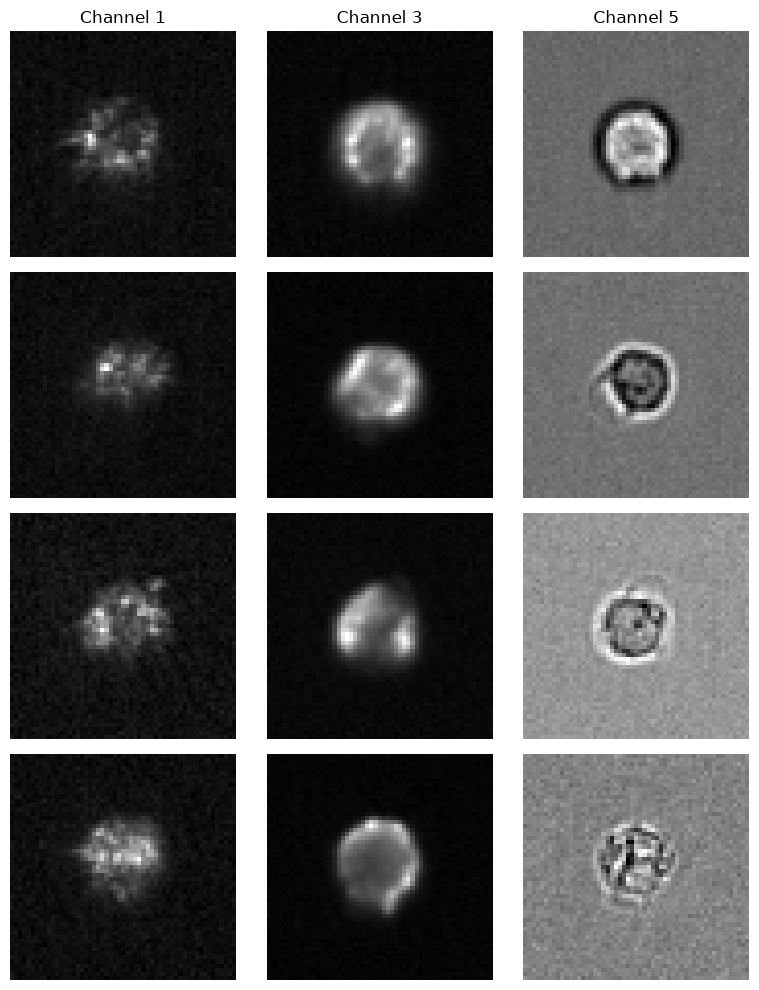

In [56]:
import random

sample_cells = random.sample(cells, 4)

fig, axes = plt.subplots(4, 3, figsize=(8, 10))

channels = ["ch1", "ch3", "ch5"]
titles = ["Channel 1", "Channel 3", "Channel 5"]

for row_idx, cell in enumerate(sample_cells):

    for col_idx, (channel, title) in enumerate(zip(channels, titles)):

        ax = axes[row_idx, col_idx]

        ax.imshow(cell[channel], cmap="gray")

        if row_idx == 0:
            ax.set_title(title)

        if col_idx == 0:
            ax.set_ylabel(
                f'{cell["subject"]}\n'
                f'{cell["class_name"]}\n'
                f'cell={cell["cell_id"]}'
            )

        ax.axis("off")

plt.tight_layout()
plt.show()

CRF022 / B / batch2 / montage 1: 193 cells


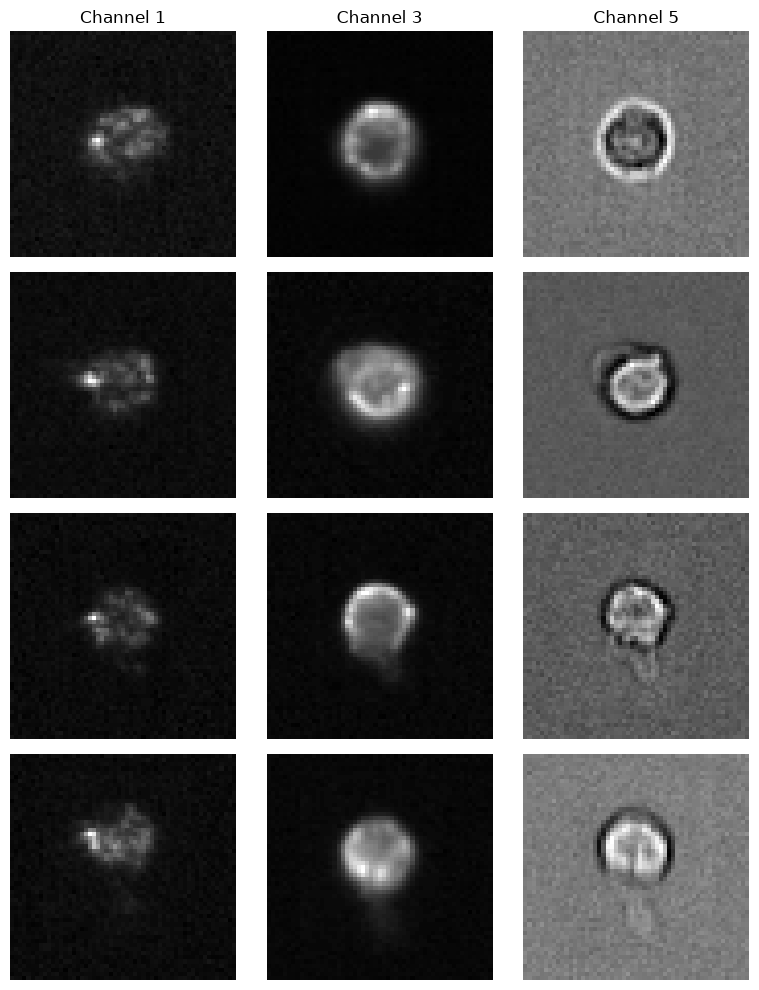

In [57]:
cells_batch2 = cell_batch("CRF022", "B", "batch2")
import random

sample_cells = random.sample(cells, 4)

fig, axes = plt.subplots(4, 3, figsize=(8, 10))

channels = ["ch1", "ch3", "ch5"]
titles = ["Channel 1", "Channel 3", "Channel 5"]

for row_idx, cell in enumerate(sample_cells):

    for col_idx, (channel, title) in enumerate(zip(channels, titles)):

        ax = axes[row_idx, col_idx]

        ax.imshow(cell[channel], cmap="gray")

        if row_idx == 0:
            ax.set_title(title)

        if col_idx == 0:
            ax.set_ylabel(
                f'{cell["subject"]}\n'
                f'{cell["class_name"]}\n'
                f'cell={cell["cell_id"]}'
            )

        ax.axis("off")

plt.tight_layout()
plt.show()

CRF022 / B / batch3 / montage 1: 143 cells


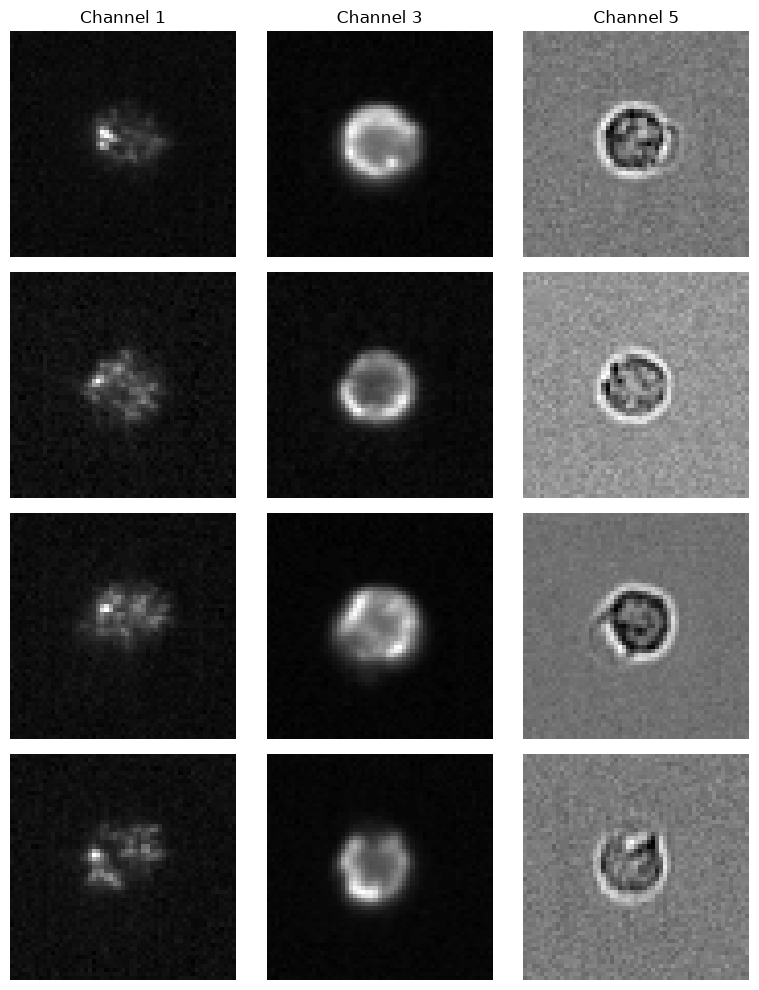

In [58]:
cells_batch3 = cell_batch("CRF022", "B", "batch3")
import random

sample_cells = random.sample(cells, 4)

fig, axes = plt.subplots(4, 3, figsize=(8, 10))

channels = ["ch1", "ch3", "ch5"]
titles = ["Channel 1", "Channel 3", "Channel 5"]

for row_idx, cell in enumerate(sample_cells):

    for col_idx, (channel, title) in enumerate(zip(channels, titles)):

        ax = axes[row_idx, col_idx]

        ax.imshow(cell[channel], cmap="gray")

        if row_idx == 0:
            ax.set_title(title)

        if col_idx == 0:
            ax.set_ylabel(
                f'{cell["subject"]}\n'
                f'{cell["class_name"]}\n'
                f'cell={cell["cell_id"]}'
            )

        ax.axis("off")

plt.tight_layout()
plt.show()

In [59]:
cells_list = cells + cells_batch2 + cells_batch3
print("Total cells:", len(cells_list))
print("batch1:", len(cells))
print("batch2:", len(cells_batch2))
print("batch3:", len(cells_batch3))
print("total :", len(cells_list))


Total cells: 533
batch1: 197
batch2: 193
batch3: 143
total : 533


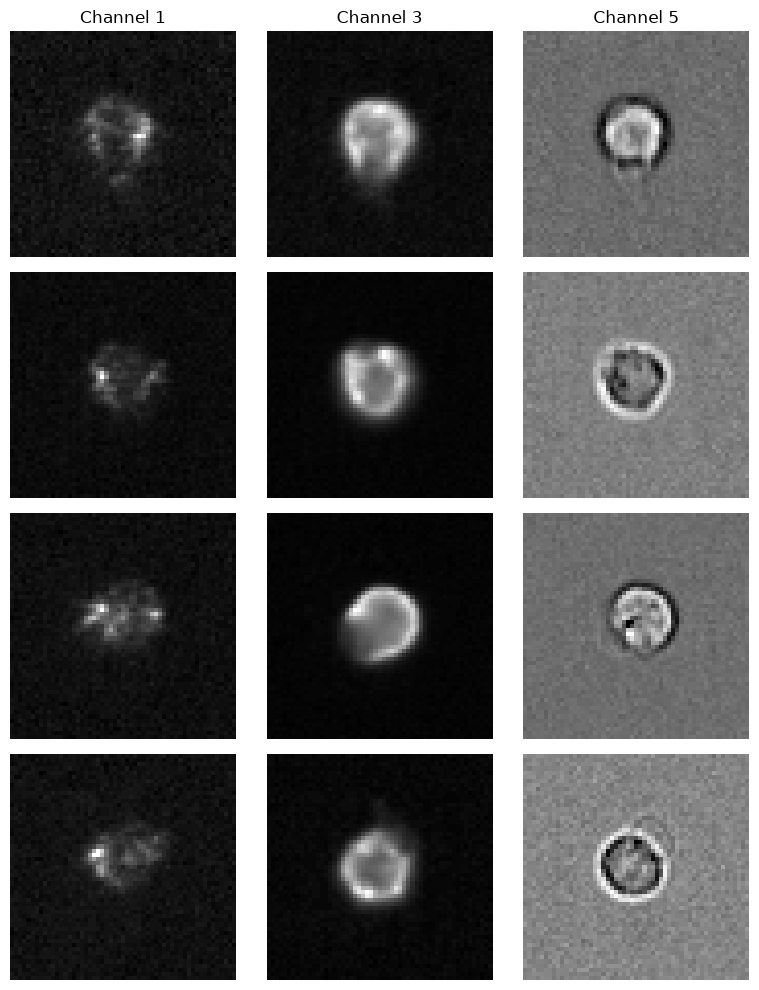

In [60]:
import random

sample_cells = random.sample(cells, 4)

fig, axes = plt.subplots(4, 3, figsize=(8, 10))

channels = ["ch1", "ch3", "ch5"]
titles = ["Channel 1", "Channel 3", "Channel 5"]

for row_idx, cell in enumerate(sample_cells):

    for col_idx, (channel, title) in enumerate(zip(channels, titles)):

        ax = axes[row_idx, col_idx]

        ax.imshow(cell[channel], cmap="gray")

        if row_idx == 0:
            ax.set_title(title)

        if col_idx == 0:
            ax.set_ylabel(
                f'{cell["subject"]}\n'
                f'{cell["class_name"]}\n'
                f'cell={cell["cell_id"]}'
            )

        ax.axis("off")

plt.tight_layout()
plt.show()

In [62]:
def batch_processor(subject, class_name):
    class_dir = BASE_DIR / subject / class_name

    batch_dirs = sorted([
        folder.name
        for folder in class_dir.iterdir()
        if folder.is_dir() and folder.name.startswith("batch")
    ])
    print(batch_dirs)
    all_cells = []

    for batch_name in batch_dirs:
        batch_cells = cell_batch(
            subject,
            class_name,
            batch_name
        )

        all_cells.extend(batch_cells)

    return all_cells

In [63]:
batch_processor("CRF022", "T")

['batch1', 'batch2']
CRF022 / T / batch1 / montage 1: 900 cells
CRF022 / T / batch1 / montage 2: 1 cells
CRF022 / T / batch2 / montage 1: 900 cells
CRF022 / T / batch2 / montage 2: 15 cells


[{'subject': 'CRF022',
  'class_name': 'T',
  'batch': 'batch1',
  'montage_id': '1',
  'cell_id': 0,
  'row': 0,
  'col': 0,
  'ch1': array([[0.00048994, 0.00050853, 0.0004972 , ..., 0.00049816, 0.00050502,
          0.00050113],
         [0.00048363, 0.00050506, 0.00049834, ..., 0.00049992, 0.00050062,
          0.00048428],
         [0.00047357, 0.0004966 , 0.00050415, ..., 0.00049027, 0.00048087,
          0.00049021],
         ...,
         [0.0004989 , 0.00049935, 0.00050239, ..., 0.00048273, 0.00048647,
          0.00049259],
         [0.00049502, 0.00048265, 0.00051283, ..., 0.00050375, 0.00049576,
          0.00049994],
         [0.00049658, 0.00048044, 0.00047927, ..., 0.00049513, 0.00048589,
          0.00049464]], shape=(55, 55), dtype=float32),
  'ch3': array([[0.0006399 , 0.0005995 , 0.00061603, ..., 0.00061366, 0.0006265 ,
          0.00064084],
         [0.00062079, 0.00062822, 0.00062463, ..., 0.00062538, 0.0006256 ,
          0.00059446],
         [0.00062075, 0.00059

In [53]:
data_dir = BASE_DIR / "CRF022" / "T" / "batch1"

print(list(data_dir.glob("*.tif")))
print("ch1:", list(data_dir.glob("ch1_*.tif")))
print("ch3:", list(data_dir.glob("ch3_*.tif")))
print("ch5:", list(data_dir.glob("ch5_*.tif")))

[WindowsPath('C:/Users/User/Desktop/白血球画像分類/Stained_Montages/CRF022/T/batch1/ch1_1.tif'), WindowsPath('C:/Users/User/Desktop/白血球画像分類/Stained_Montages/CRF022/T/batch1/ch1_2.tif'), WindowsPath('C:/Users/User/Desktop/白血球画像分類/Stained_Montages/CRF022/T/batch1/ch3_1.tif'), WindowsPath('C:/Users/User/Desktop/白血球画像分類/Stained_Montages/CRF022/T/batch1/ch3_2.tif'), WindowsPath('C:/Users/User/Desktop/白血球画像分類/Stained_Montages/CRF022/T/batch1/ch5_1.tif'), WindowsPath('C:/Users/User/Desktop/白血球画像分類/Stained_Montages/CRF022/T/batch1/ch5_2.tif')]
ch1: [WindowsPath('C:/Users/User/Desktop/白血球画像分類/Stained_Montages/CRF022/T/batch1/ch1_1.tif'), WindowsPath('C:/Users/User/Desktop/白血球画像分類/Stained_Montages/CRF022/T/batch1/ch1_2.tif')]
ch3: [WindowsPath('C:/Users/User/Desktop/白血球画像分類/Stained_Montages/CRF022/T/batch1/ch3_1.tif'), WindowsPath('C:/Users/User/Desktop/白血球画像分類/Stained_Montages/CRF022/T/batch1/ch3_2.tif')]
ch5: [WindowsPath('C:/Users/User/Desktop/白血球画像分類/Stained_Montages/CRF022/T/batch1/ch5_1.tif'), Wi

In [68]:
def batch_visualiser(cells, channels, titles,n):

    fig, axes = plt.subplots(
        len(cells),
        len(channels),
        figsize=(9, 3 * len(cells))
    )

    for row_idx, cell in enumerate(cells):

        for col_idx, (channel, title) in enumerate(zip(channels, titles)):

            ax = axes[row_idx, col_idx]

            ax.imshow(cell[channel], cmap="gray")

            if row_idx == 0:
                ax.set_title(title)

            if col_idx == 0:
                ax.set_ylabel(
                    f'{cell["subject"]}\n'
                    f'{cell["class_name"]}\n'
                    f'{cell["batch"]}\n'
                    f'montage={cell["montage_id"]}\n'
                    f'cell={cell["cell_id"]}'
                )

            ax.axis("off")

    plt.tight_layout()
    plt.show()

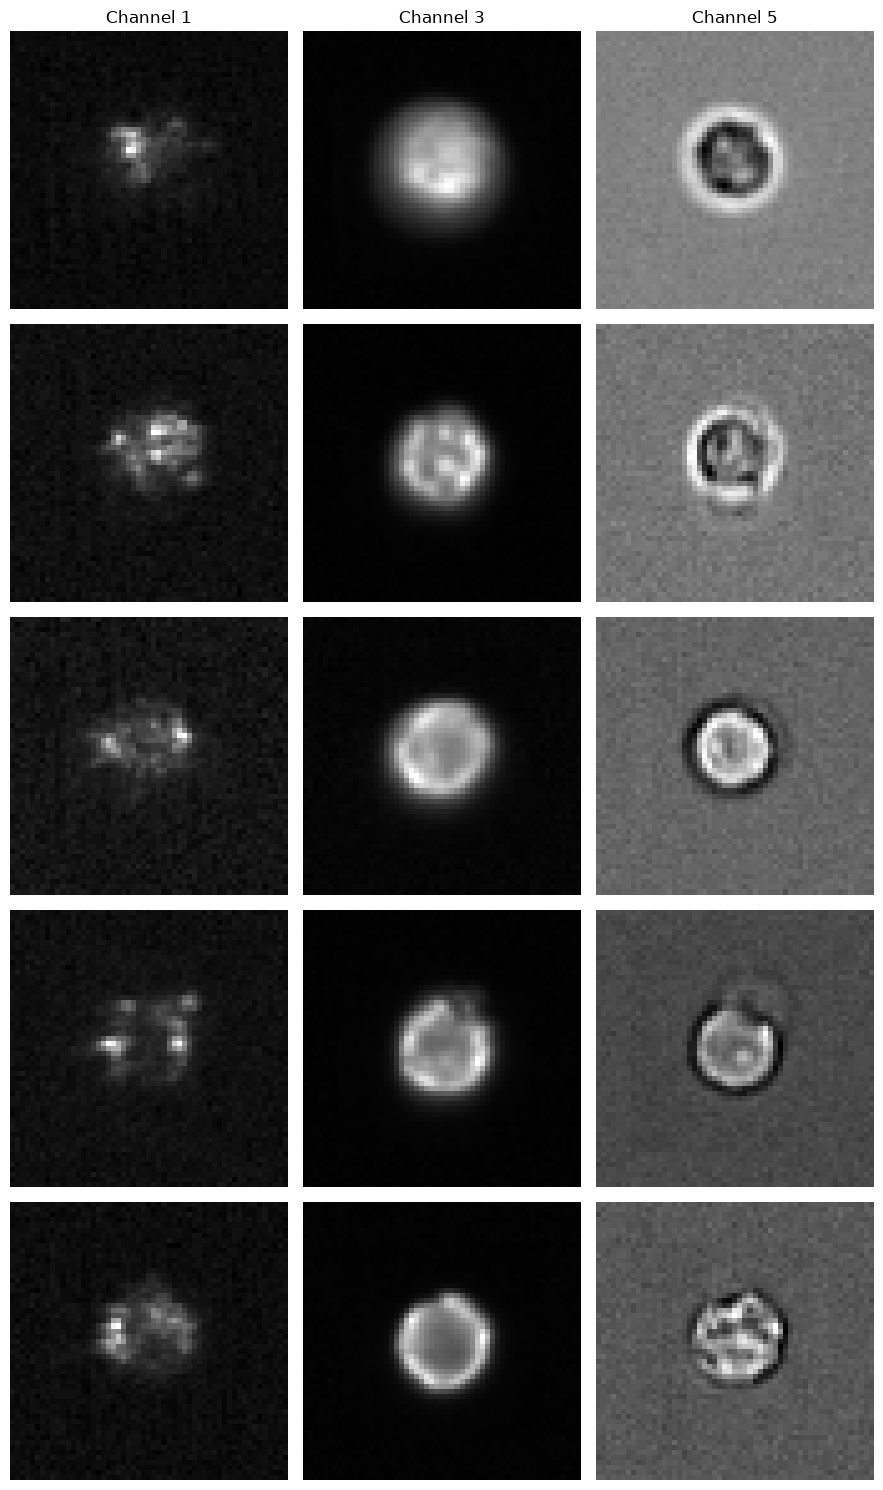

In [69]:
montage1_cells = [
    cell for cell in cells_T
    if cell["batch"] == "batch1"
    and cell["montage_id"] == "1"
]
check_ids = [0, 100, 300, 600, 899]

sample_cells = [
    montage1_cells[i]
    for i in check_ids
]
batch_visualiser(
    sample_cells,
    channels,
    titles,
    n=5
)

['batch1', 'batch2']
CRF022 / eosinophil / batch1 / montage 1: 270 cells
CRF022 / eosinophil / batch2 / montage 1: 1 cells


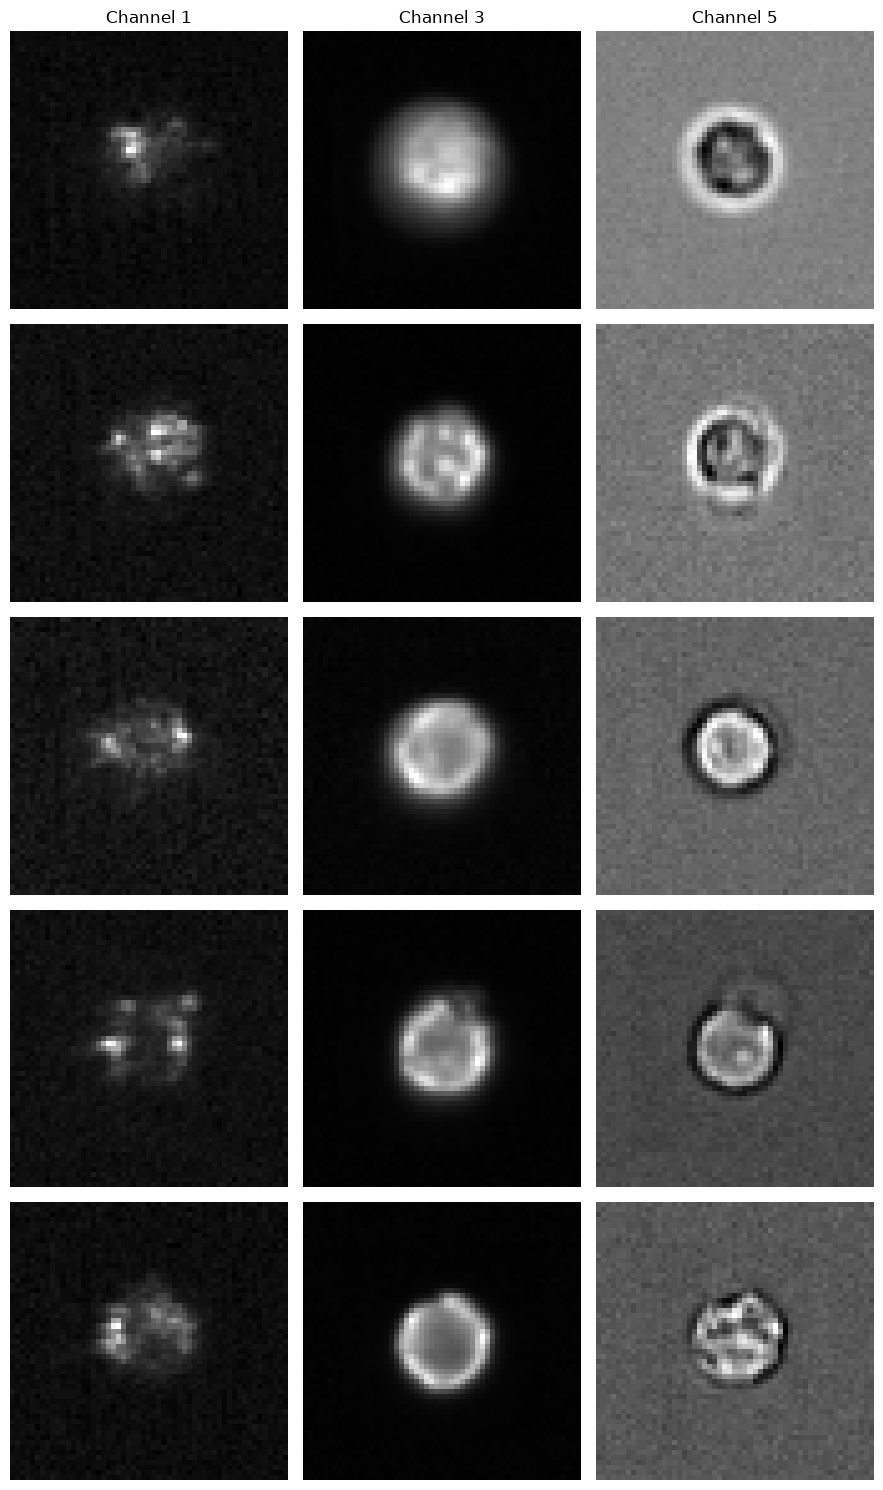

In [72]:
batch_processor("CRF022", "eosinophil")
montage1_cells = [
    cell for cell in cells_T
    if cell["batch"] == "batch1"
    and cell["montage_id"] == "1"
]
check_ids = [0, 100, 300, 600, 899]

sample_cells = [
    montage1_cells[i]
    for i in check_ids
]
batch_visualiser(
    sample_cells,
    channels,
    titles,
    n=5
)

['batch1']
CRF022 / monocyte / batch1 / montage 1: 346 cells


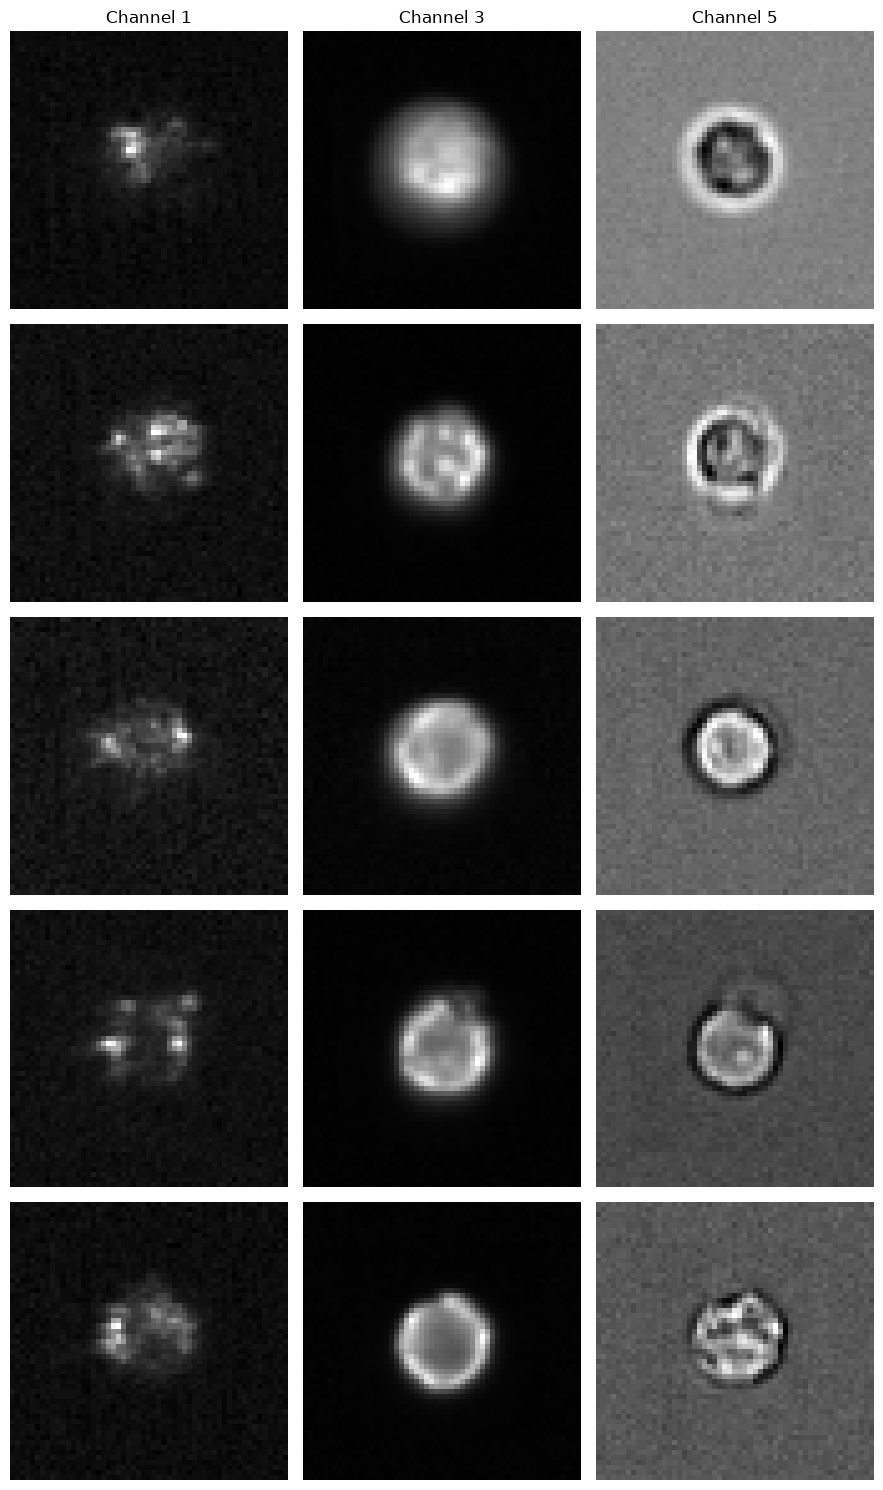

In [73]:
batch_processor("CRF022", "monocyte")
montage1_cells = [
    cell for cell in cells_T
    if cell["batch"] == "batch1"
    and cell["montage_id"] == "1"
]
check_ids = [0, 100, 300, 600, 899]

sample_cells = [
    montage1_cells[i]
    for i in check_ids
]
batch_visualiser(
    sample_cells,
    channels,
    titles,
    n=5
)

['batch1', 'batch2']
CRF022 / neutrophil / batch1 / montage 1: 813 cells
CRF022 / neutrophil / batch2 / montage 1: 880 cells


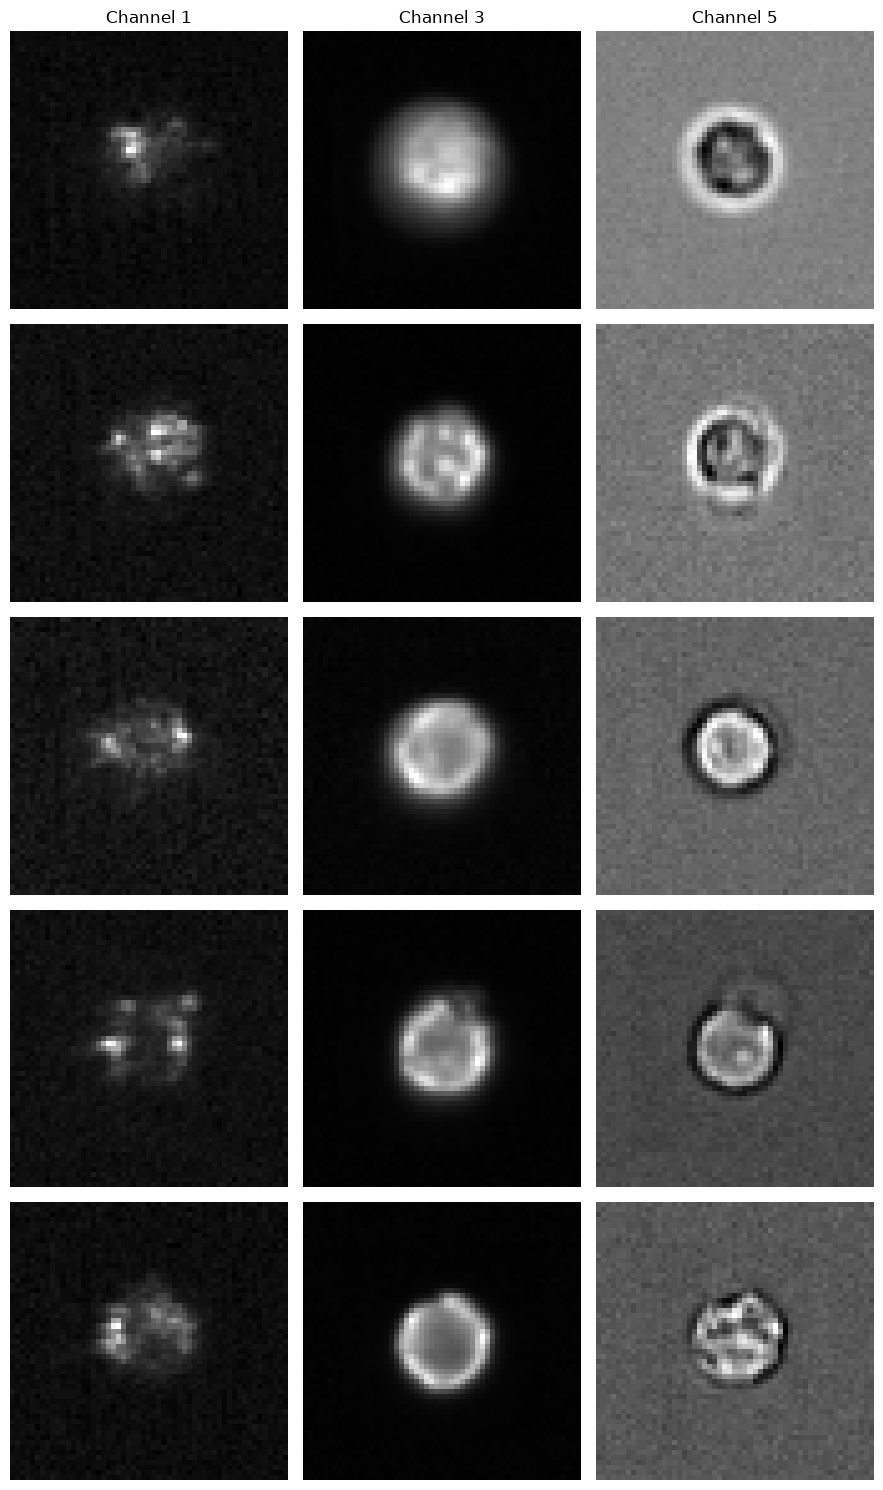

In [74]:
batch_processor("CRF022", "neutrophil")
montage1_cells = [
    cell for cell in cells_T
    if cell["batch"] == "batch1"
    and cell["montage_id"] == "1"
]
check_ids = [0, 100, 300, 600, 899]

sample_cells = [
    montage1_cells[i]
    for i in check_ids
]
batch_visualiser(
    sample_cells,
    channels,
    titles,
    n=5
)

In [76]:
cells_B = batch_processor("CRF022", "B")
cells_T = batch_processor("CRF022", "T")
cells_eosinophil = batch_processor("CRF022", "eosinophil")
cells_monocyte = batch_processor("CRF022", "monocyte")
cells_neutrophil = batch_processor("CRF022", "neutrophil")

import pandas as pd
class_counts = {
    "B": len(cells_B),
    "T": len(cells_T),
    "eosinophil": len(cells_eosinophil),
    "monocyte": len(cells_monocyte),
    "neutrophil": len(cells_neutrophil)
}

df_counts = pd.DataFrame(
    class_counts.items(),
    columns=["class", "number_of_cells"]
)

df_counts

['batch1', 'batch2', 'batch3']
CRF022 / B / batch1 / montage 1: 197 cells
CRF022 / B / batch2 / montage 1: 193 cells
CRF022 / B / batch3 / montage 1: 143 cells
['batch1', 'batch2']
CRF022 / T / batch1 / montage 1: 900 cells
CRF022 / T / batch1 / montage 2: 1 cells
CRF022 / T / batch2 / montage 1: 900 cells
CRF022 / T / batch2 / montage 2: 15 cells
['batch1', 'batch2']
CRF022 / eosinophil / batch1 / montage 1: 270 cells
CRF022 / eosinophil / batch2 / montage 1: 1 cells
['batch1']
CRF022 / monocyte / batch1 / montage 1: 346 cells
['batch1', 'batch2']
CRF022 / neutrophil / batch1 / montage 1: 813 cells
CRF022 / neutrophil / batch2 / montage 1: 880 cells


,class,number_of_cells
0,B,533
1,T,1816
2,eosinophil,271
3,monocyte,346
4,neutrophil,1693
